In [1]:
import os

# Mengecek direktori saat ini
current_dir = os.getcwd()
print("Direktori awal:", current_dir)

# Jika masih di dalam folder 'notebooks', naik satu tingkat ke folder root proyek
if current_dir.endswith('notebooks'):
    os.chdir('..')
    print("Direktori setelah disesuaikan:", os.getcwd())


Direktori awal: d:\pokemon-tcg-classification\notebooks
Direktori setelah disesuaikan: d:\pokemon-tcg-classification


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalMaxPooling2D, Dropout, BatchNormalization, Cropping2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
# ==========================================
# KONFIGURASI DIREKTORI & PARAMETER
# ==========================================
TRAIN_DIR = os.path.join('data', 'processed', 'train')
VAL_DIR = os.path.join('data', 'processed', 'val')
TEST_DIR = os.path.join('data', 'processed', 'test')

# Resolusi Tinggi untuk mempertahankan detail mikroskopis simbol set
IMG_HEIGHT = 588
IMG_WIDTH = 420
BATCH_SIZE = 16 
NUM_CLASSES = 10

# ==========================================
# DATA GENERATOR DENGAN PREPROCESS_INPUT NATIVE
# ==========================================
print("Menyiapkan Data Generator...")

# PENTING: rescale=1./255 dihapus, diganti dengan preprocess_input bawaan MobileNetV2
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, 
    brightness_range=[0.8, 1.2] # Hanya augmentasi fotometrik
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='categorical'
)
val_generator = val_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='categorical'
)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

# Menghitung bobot kelas untuk menangani ketidakseimbangan data
class_weights = compute_class_weight('balanced', classes=np.unique(train_generator.classes), y=train_generator.classes)
class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weight_dict)


Menyiapkan Data Generator...
Found 1605 images belonging to 10 classes.
Found 340 images belonging to 10 classes.
Found 355 images belonging to 10 classes.
Class Weights: {0: np.float64(1.1145833333333333), 1: np.float64(0.9441176470588235), 2: np.float64(0.9786585365853658), 3: np.float64(1.2067669172932332), 4: np.float64(0.9331395348837209), 5: np.float64(0.823076923076923), 6: np.float64(0.9385964912280702), 7: np.float64(1.284), 8: np.float64(1.0354838709677419), 9: np.float64(0.9119318181818182)}


In [4]:
print("Membangun Arsitektur Extreme Micro-RoI...")

inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# 1. MICRO-CROPPING (Fokus Ekstrem)
# Membuang 85% atas dan 70% kanan. 
# Hanya menyisakan area sangat kecil di pojok kiri bawah (tempat simbol set & rarity).
top_crop = int(IMG_HEIGHT * 0.85)
bottom_crop = 0
left_crop = 0
right_crop = int(IMG_WIDTH * 0.70)

x = Cropping2D(cropping=((top_crop, bottom_crop), (left_crop, right_crop)), name='micro_roi_cropping')(inputs)

# 2. Base Model MobileNetV2
base_model = MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=(None, None, 3) 
)
base_model.trainable = False 

x = base_model(x)

# 3. Global Max Pooling
x = GlobalMaxPooling2D()(x)

# 4. Classifier Layers (Kapasitas dioptimalkan)
x = BatchNormalization()(x)
x = Dropout(0.5)(x) 
x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=inputs, outputs=predictions)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()


Membangun Arsitektur Extreme Micro-RoI...


C:\Users\aryay\AppData\Local\Temp\ipykernel_9024\1622355022.py:16: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 588, 420, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ micro_roi_cropping (Cropping2D) │ (None, 89, 126, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 1280)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,610 (9.89 MB)

 Trainable params: 333,066 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [5]:
# --- TAHAP 1: FEATURE EXTRACTION ---
print("\n=== Memulai Tahap 1: Feature Extraction ===")
history_phase1 = model.fit(
    train_generator, 
    epochs=15, 
    validation_data=val_generator, 
    class_weight=class_weight_dict
)



=== Memulai Tahap 1: Feature Extraction ===
Epoch 1/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 92s 816ms/step - accuracy: 0.2735 - loss: 6.7107 - val_accuracy: 0.4912 - val_loss: 5.2785
Epoch 2/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 31s 303ms/step - accuracy: 0.3950 - loss: 5.4559 - val_accuracy: 0.5441 - val_loss: 4.5686
Epoch 3/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 34s 342ms/step - accuracy: 0.4442 - loss: 4.7580 - val_accuracy: 0.6235 - val_loss: 4.0763
Epoch 4/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 330ms/step - accuracy: 0.4997 - loss: 4.1255 - val_accuracy: 0.6324 - val_loss: 3.6395
Epoch 5/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 32s 315ms/step - accuracy: 0.5352 - loss: 3.6310 - val_accuracy: 0.6588 - val_loss: 3.2889
Epoch 6/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 31s 303ms/step - accuracy: 0.5607 - loss: 3.2601 - val_accuracy: 0.7029 - val_loss: 2.9431
Epoch 7/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 34s 335ms/step - accuracy: 0.5869 - loss: 2.9597 - val_accuracy: 0.6853 - val_loss: 2.7145
Epoch 8/15
101/101 ━━━━━━━━━━━━━━━━━━━

In [6]:
# --- TAHAP 2: DEEP FINE-TUNING ---
print("\n=== Memulai Tahap 2: Deep Fine-Tuning (>90% Target) ===")
base_model.trainable = True

# PENTING: Membekukan hanya 50% layer awal (sebelumnya 75%)
# Ini memungkinkan model memodifikasi filter konvolusi menengahnya untuk mengenali teks/simbol
freeze_until = int(len(base_model.layers) * 0.50)
for layer in base_model.layers[:freeze_until]:
    layer.trainable = False

# Learning rate dijaga sangat rendah agar bobot tidak "meledak" saat 50% layer dibuka
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5), 
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Kesabaran callback dinaikkan agar model punya waktu untuk beradaptasi dengan fitur baru
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)

# Epoch ditingkatkan menjadi 40 untuk memberi ruang Deep Fine-Tuning bekerja maksimal
history_phase2 = model.fit(
    train_generator, 
    epochs=40, 
    validation_data=val_generator, 
    callbacks=[early_stop, reduce_lr], 
    class_weight=class_weight_dict
)



=== Memulai Tahap 2: Deep Fine-Tuning (>90% Target) ===
Epoch 1/40
101/101 ━━━━━━━━━━━━━━━━━━━━ 56s 400ms/step - accuracy: 0.2411 - loss: 3.0153 - val_accuracy: 0.5000 - val_loss: 2.4167 - learning_rate: 5.0000e-05
Epoch 2/40
101/101 ━━━━━━━━━━━━━━━━━━━━ 38s 379ms/step - accuracy: 0.3682 - loss: 2.6054 - val_accuracy: 0.4765 - val_loss: 2.4993 - learning_rate: 5.0000e-05
Epoch 3/40
101/101 ━━━━━━━━━━━━━━━━━━━━ 38s 376ms/step - accuracy: 0.4847 - loss: 2.3625 - val_accuracy: 0.4912 - val_loss: 2.4930 - learning_rate: 5.0000e-05
Epoch 4/40
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.5476 - loss: 2.2073
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
101/101 ━━━━━━━━━━━━━━━━━━━━ 38s 378ms/step - accuracy: 0.5520 - loss: 2.1947 - val_accuracy: 0.5176 - val_loss: 2.4231 - learning_rate: 5.0000e-05
Epoch 5/40
101/101 ━━━━━━━━━━━━━━━━━━━━ 38s 375ms/step - accuracy: 0.6044 - loss: 2.0490 - val_accuracy: 0.5265 - val_loss: 2.4038 - learning_rate: 2.5000

In [7]:
# Menyimpan model menggunakan format native Keras terbaru
os.makedirs('models', exist_ok=True)
model_path = os.path.join('models', 'mobilenetv2_pokemon_tcg.keras')
model.save(model_path)
print(f"Model berhasil disimpan di: {model_path}")


Model berhasil disimpan di: models\mobilenetv2_pokemon_tcg.keras


Mengevaluasi model pada Test Set...
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 554ms/step - accuracy: 0.9070 - loss: 1.1920

Akurasi pada Test Set: 90.70%

=== Laporan Klasifikasi (Classification Report) ===
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 299ms/step
                       precision    recall  f1-score   support

                  151       0.97      0.88      0.92        32
      destined-rivals       0.90      0.95      0.92        38
       evolving-skies       0.87      0.94      0.91        36
     journey-together       0.81      0.86      0.83        29
          lost-origin       0.92      0.87      0.89        38
       paldea-evolved       0.91      0.98      0.94        43
        paldean-fates       1.00      0.92      0.96        38
 prismatic-evolutions       0.96      0.79      0.86        28
scarlet-violet-promos       0.91      0.85      0.88        34
       surging-sparks       0.86      0.97      0.92        39

             accuracy                           0.91       355
     

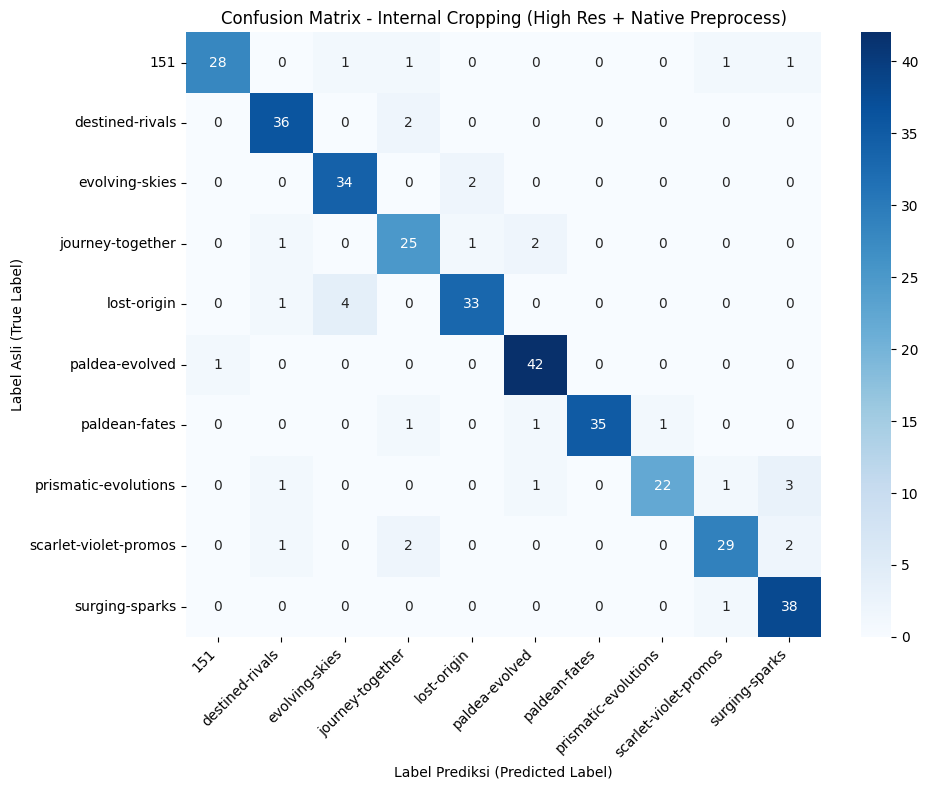

In [8]:
print("Mengevaluasi model pada Test Set...")
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nAkurasi pada Test Set: {test_acc * 100:.2f}%")

print("\n=== Laporan Klasifikasi (Classification Report) ===")
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Internal Cropping (High Res + Native Preprocess)')
plt.ylabel('Label Asli (True Label)')
plt.xlabel('Label Prediksi (Predicted Label)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Menyimpan gambar Confusion Matrix
os.makedirs('reports', exist_ok=True)
cm_path = os.path.join('reports', 'confusion_matrix_mobilenet.png')
plt.savefig(cm_path)
print(f"Confusion Matrix berhasil disimpan di: {cm_path}")

plt.show()


Menghasilkan Learning Curves...
Learning Curves berhasil disimpan di: reports\learning_curves_mobilenet.png


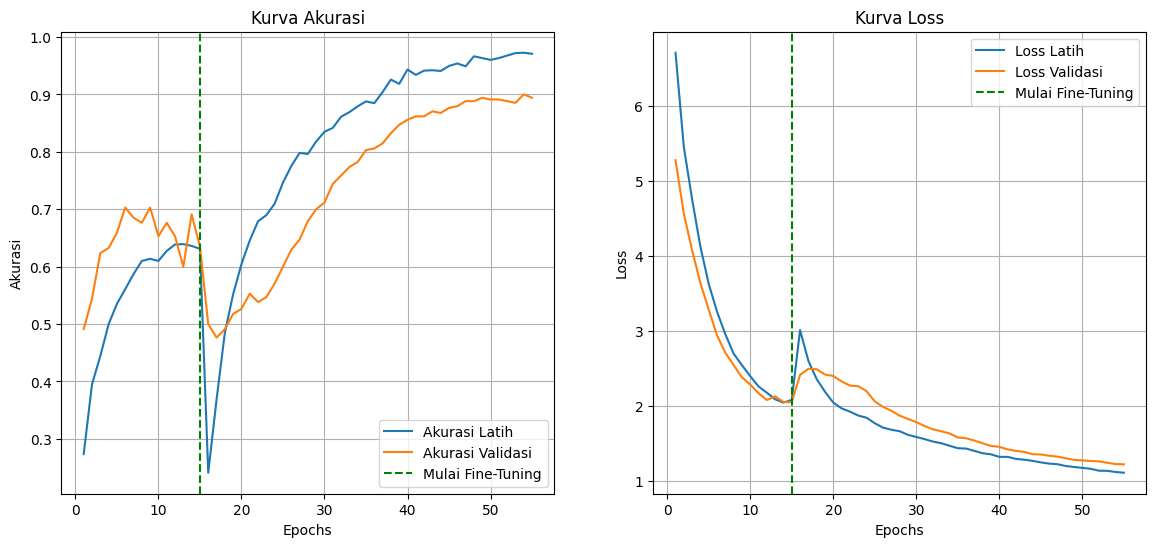

In [9]:
print("Menghasilkan Learning Curves...")

# Menggabungkan log dari Tahap 1 dan Tahap 2
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']

loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

initial_epochs = len(history_phase1.history['accuracy'])
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 6))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Akurasi Latih')
plt.plot(epochs_range, val_acc, label='Akurasi Validasi')
plt.axvline(x=initial_epochs, color='green', linestyle='--', label='Mulai Fine-Tuning')
plt.title('Kurva Akurasi')
plt.xlabel('Epochs')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss Latih')
plt.plot(epochs_range, val_loss, label='Loss Validasi')
plt.axvline(x=initial_epochs, color='green', linestyle='--', label='Mulai Fine-Tuning')
plt.title('Kurva Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

lc_path = os.path.join('reports', 'learning_curves_mobilenet.png')
plt.savefig(lc_path)
print(f"Learning Curves berhasil disimpan di: {lc_path}")

plt.show()
